In [1]:
import os

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="2"

In [2]:
from setproctitle import setproctitle
setproctitle("TRAINING_DDQN_WITH_IMPROVEMENTS")

In [3]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu, True)

2025-04-25 19:59:40.696594: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-25 19:59:40.696632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-25 19:59:40.697852: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-25 19:59:40.704464: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-25 19:59:41.311009: W tensorflow/compiler/tf2

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np
from tqdm import trange
from UltimateTicTacToeEnvSelfPlay import UltimateTicTacToeEnvSelfPlay
from DoubleDQNAgent_with_improvements import DoubleDQNAgent
import matplotlib.pyplot as plt

In [6]:
def asses_performance_dqn(agent):
    NUM_OF_GAMES = 500
    performance_envs = [UltimateTicTacToeEnvSelfPlay() for _ in range(NUM_OF_GAMES)]
    dones = np.zeros((NUM_OF_GAMES,), dtype=bool)
    final_rewards = np.zeros((NUM_OF_GAMES,))
    while(not np.all(dones) != 0):
        performance_states = np.array([env.to_state()[0] for env in performance_envs])
        performance_available_actions = np.array([env.to_state()[1] for env in performance_envs])
        performance_actions = agent.choose_action(performance_states, performance_available_actions, True)
        performance_r1 = np.zeros(NUM_OF_GAMES)
        game_finished = np.zeros(NUM_OF_GAMES)
        for i in range(NUM_OF_GAMES):
          if dones[i] == True:
            continue
          _, performance_r1[i], game_finished[i], _  = performance_envs[i].step(performance_actions[i])
          if game_finished[i] == True:
              dones[i] = True
              final_rewards[i] = performance_r1[i]

        states_opponent = np.array([env.to_state()[0] for env in performance_envs])
        available_actions_opponent = np.array([env.to_state()[1] for env in performance_envs])
        actions_opponent = np.full(available_actions_opponent.shape[0], -1, dtype=int)
        one_indices = available_actions_opponent == 1
        # For each row where there is at least one '1', select a random index of '1'
        for i in range(available_actions_opponent.shape[0]):
            valid_indices = np.where(one_indices[i])[0]
            if valid_indices.size > 0:
                actions_opponent[i] = np.random.choice(valid_indices)
        performance_r2 = np.zeros(NUM_OF_GAMES)
        game_finished = np.zeros(NUM_OF_GAMES)
        for i in range(NUM_OF_GAMES):
              if dones[i] == True:
                continue
              _, performance_r2[i], game_finished[i], _  = performance_envs[i].step(actions_opponent[i])
              if game_finished[i] == True:
                  dones[i] = True
                  final_rewards[i] = -performance_r2[i]

    return np.count_nonzero(final_rewards == 1)/len(dones), np.count_nonzero(final_rewards == 0)/len(dones)

In [7]:
def asses_performance_dqn_inverse(agent):
    NUM_OF_GAMES = 500
    performance_envs = [UltimateTicTacToeEnvSelfPlay() for _ in range(NUM_OF_GAMES)]
    dones = np.zeros((NUM_OF_GAMES,), dtype=bool)
    final_rewards = np.zeros((NUM_OF_GAMES,))
    while(not np.all(dones) != 0):
        performance_available_actions = np.array([env.to_state()[1] for env in performance_envs])
        performance_actions = np.full(performance_available_actions.shape[0], -1, dtype=int)
        performance_r1 = np.zeros(NUM_OF_GAMES)
        game_finished = np.zeros(NUM_OF_GAMES)
        one_indices = performance_available_actions == 1
        # For each row where there is at least one '1', select a random index of '1'
        for i in range(performance_available_actions.shape[0]):
            valid_indices = np.where(one_indices[i])[0]
            if valid_indices.size > 0:
                performance_actions[i] = np.random.choice(valid_indices)
        for i in range(NUM_OF_GAMES):
            if dones[i] == True:
                continue
            _, performance_r1[i], game_finished[i], _  = performance_envs[i].step(performance_actions[i])
            if game_finished[i] == True:
                    dones[i] = True
                    final_rewards[i] = performance_r1[i]

        states_opponent = np.array([env.to_state()[0] for env in performance_envs])
        available_actions_opponent = np.array([env.to_state()[1] for env in performance_envs])
        actions_opponent = agent.choose_action(states_opponent, available_actions_opponent, True)
        performance_r2 = np.zeros(NUM_OF_GAMES)
        game_finished = np.zeros(NUM_OF_GAMES)
        for i in range(NUM_OF_GAMES):
              if dones[i] == True:
                continue
              _, performance_r2[i], game_finished[i], _  = performance_envs[i].step(actions_opponent[i])
              if game_finished[i] == True:
                  dones[i] = True
                  final_rewards[i] = -performance_r2[i]

    return np.count_nonzero(final_rewards == -1)/len(dones), np.count_nonzero(final_rewards == 0)/len(dones)

In [ ]:
# Initialize the Agent
GAMES = 256
ITERATIONS = 600000
DQN_rewards = []
envs = [UltimateTicTacToeEnvSelfPlay() for _ in range(GAMES)]
states = envs[0].to_state()[0]
state_space_shape = states.shape
action_space_size = 81
agent = DoubleDQNAgent(action_space_size, state_space_shape, exploration_rate=1.00, learning_rate=0.0002, target_update_frequency=20, soft_update=True)

performance_dqn = []
draws_dqn = []
performance_with_draws_dqn = []

states = np.array([env.to_state()[0] for env in envs])
available_actions = np.array([env.to_state()[1] for env in envs])
actions = agent.choose_action(states, available_actions)
r1 = np.zeros(GAMES)
exploration_rate_history = np.zeros(ITERATIONS)
for i in range(GAMES):
    r1[i] = envs[i].step(actions[i])[1]

# Training Loop
for episode in trange(ITERATIONS):

    if episode % 1000 == 0:
        win, draw = asses_performance_dqn(agent)
        win_inverse, draw_inverse = asses_performance_dqn_inverse(agent)
        performance_dqn.append((win+win_inverse)/2)
        draws_dqn.append((draw+draw_inverse)/2)
        performance_with_draws_dqn.append((win+win_inverse+draw+draw_inverse)/2)

    states_opponent = np.array([env.to_state()[0] for env in envs])
    available_actions_opponent = np.array([env.to_state()[1] for env in envs])
    actions_opponent = agent.choose_action(states_opponent, available_actions_opponent)
    r2 = np.zeros(GAMES)
    dones = np.zeros(GAMES, dtype=bool)
    for i in range(GAMES):
        _, r2[i], dones[i], _ = envs[i].step(actions_opponent[i])
    rewards = r1 - r2
    DQN_rewards.append(np.average(rewards))
    next_states = np.array([env.to_state()[0] for env in envs])
    next_states_available_actions = np.array([env.to_state()[1] for env in envs])

    agent.update_q_values(states, actions, rewards, next_states, dones, next_states_available_actions, episode)

    if(not agent.exploration_rate <= 0.05):
        new_er = 0.05 + (1.0 - 0.05) * np.exp(-0.0001 * episode)
        agent.set_exploration_rate(new_er)
    exploration_rate_history[episode] = agent.exploration_rate

    states = states_opponent
    available_actions = available_actions_opponent
    actions = actions_opponent
    r1 = r2

2025-04-25 19:59:42.848724: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-25 19:59:42.849037: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-25 19:59:42.849277: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

 11%|█         | 67000/600000 [3:19:00<25:11:36,  5.88it/s] 

In [ ]:
# Save the model
agent.model.save("./models/Thesis_DDQN_with_improvements")

INFO:tensorflow:Assets written to: ./models/Thesis_DDQN/assets


INFO:tensorflow:Assets written to: ./models/Thesis_DDQN/assets


In [ ]:
# Check if folders exist, if not create them
if not os.path.exists("./models/Thesis_DDQN_with_improvements"):
    os.makedirs("./models/Thesis_DDQN_with_improvements")
if not os.path.exists("./models/Thesis_DDQN_with_improvements/performances"):
    os.makedirs("./models/Thesis_DDQN_with_improvements/performances")

# Save the win rate as wins.npy and draws.npy
np.save("./models/Thesis_DDQN_with_improvements/performances/wins", performance_dqn)
np.save("./models/Thesis_DDQN_with_improvements/performances/draws", draws_dqn)
np.save("./models/Thesis_DDQN_with_improvements/performances/losses", np.ones(len(performance_with_draws_dqn))-performance_with_draws_dqn)

In [ ]:
# Calculate loss percentages
losses_dqn = 1 - np.array(performance_dqn) - np.array(draws_dqn)

# Indices for the bars
indices = np.arange(len(performance_dqn))

# Creating the stacked bar plot
plt.figure(figsize=(10, 5))
plt.bar(indices, performance_dqn, label='Win', color='g', alpha=0.7)
plt.bar(indices, draws_dqn, bottom=performance_dqn, label='Draw', color='b', alpha=0.7)
plt.bar(indices, losses_dqn, bottom=np.add(performance_dqn, draws_dqn), label='Loss', color='r', alpha=0.7)

# Adding titles and labels
plt.xlabel('1000x iterations')
plt.ylabel('Percentage')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Set the y-axis ticks to increment by 0.1
plt.yticks(np.arange(0, 1.1, 0.1))  # Values from 0 to 1 (inclusive) in steps of 0.1

# If /plot directory does not exist, create it
if not os.path.exists('./models/Thesis_DDQN_with_improvements/plot'):
    os.makedirs('./models/Thesis_DDQN_with_improvements/plot')

# Save the plot
plt.savefig('./models/Thesis_DDQN_with_improvements/plot/victory_chart.png')
plt.close()

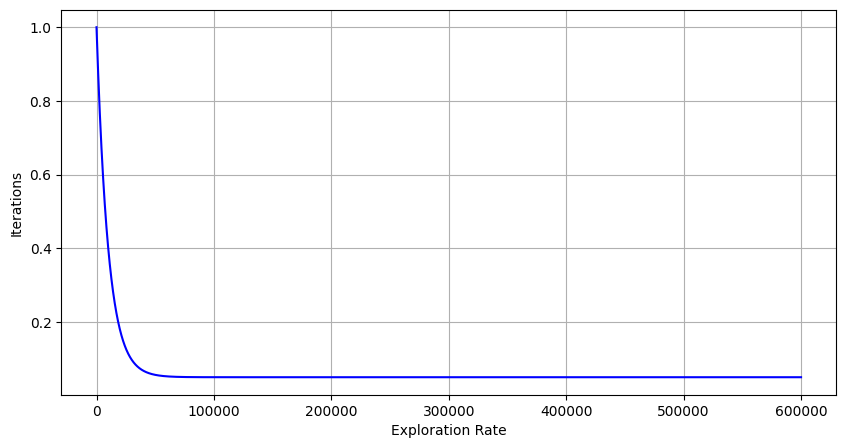

In [ ]:
# Creating a trend chart
plt.figure(figsize=(10, 5))
plt.plot(exploration_rate_history, linestyle='-', color='b')
plt.xlabel('Exploration Rate')
plt.ylabel('Iterations')
plt.grid(True)
plt.show()